# Task:2 End-to-End ML Pipeline with Scikit-learn Pipeline API

## 1. Importing Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

## 2. Loading Dataset

In [53]:
# Load the Telco Customer Churn dataset
churn = pd.read_csv("Telco-Customer-Churn.csv")

# Display the first five rows
print(churn.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## 3. Exploring Data

### Dataset Shape

In [54]:
# Display the number of rows and columns
print("Dataset Shape:")
print(churn.shape)

Dataset Shape:
(7043, 21)


### Columns Names

In [55]:
# Display all column names
print("Column Names:")
print(churn.columns)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


### First 10 Rows

In [56]:
# Display the first 10 rows
print("First 10 Rows:")
print(churn.head(5))

First 10 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

### Dataset Information

In [57]:
# Display dataset information
print("Dataset Information:")
churn.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

### Summary Statistics

In [18]:
# Display summary statistics for numerical columns
print("Summary Statistics:")
print(churn.describe())

Summary Statistics:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


### Check missing values

In [58]:
# Check for missing values
print("Missing Values:")
print(churn.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Check target variable distribution

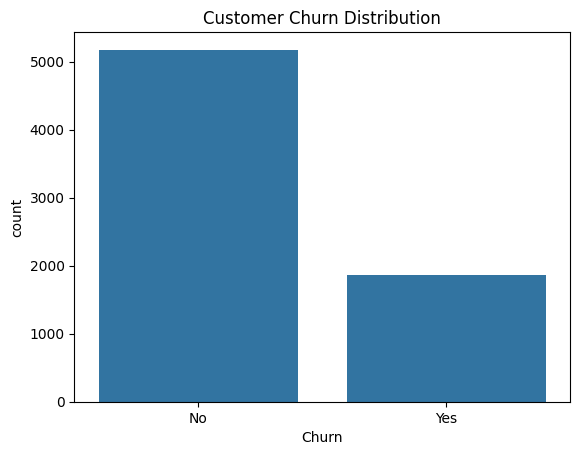

In [59]:
# Display the distribution of the target variable
sns.countplot(x='Churn', data=churn)

plt.title("Customer Churn Distribution")
plt.show()

## 4. Data Preprocessing

### Checking datatypes

In [60]:
# Display data types of all columns
print(churn.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### Replace Blank Spaces with NaN (The TotalCharges column in the Telco dataset often contains blank spaces)

In [22]:
# Replace blank spaces with NaN values
#churn['TotalCharges'] = churn['TotalCharges'].replace(' ', np.nan)

### Convert TotalCharges to normal

In [23]:
# Convert TotalCharges to numeric values
#churn['TotalCharges'] = pd.to_numeric(
 #   churn['TotalCharges']
#)

### Checking missing values again

In [24]:
# Convert TotalCharges to numeric values
#churn['TotalCharges'] = pd.to_numeric(
 #   churn['TotalCharges']
#)

### Fill missing values

In [32]:
# Fill missing values in TotalCharges using the median
churn['TotalCharges'] = churn['TotalCharges'].fillna(
    churn['TotalCharges'].median()
)
# Verify that there are no missing values
print(churn.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Convert target variable with numeric

In [61]:
print(churn['Churn'].unique())

['No' 'Yes']


In [62]:
# Convert Churn values into binary values
# Yes = 1, No = 0

churn['Churn'] = churn['Churn'].map({
    'Yes': 1,
    'No': 0
})
# Display the first few rows
print(churn[['Churn']].head())

   Churn
0      0
1      0
2      1
3      0
4      1


### Drop customer ID (Customer ID is just an identifier and should not be used for prediction)

In [63]:
# Remove customerID column
churn = churn.drop(
    'customerID',
    axis=1
)

### Separate features and target variable

In [64]:
# Separate input features and target variable

X = churn.drop(
    'Churn',
    axis=1
)

y = churn['Churn']

### Separate numerical and categorical features

In [65]:
# Select numerical features
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

# Select categorical features
categorical_features = X.select_dtypes(
    include=['object']
).columns

print("Numerical Features:")
print(numeric_features)

print()

print("Categorical Features:")
print(categorical_features)

Numerical Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

Categorical Features:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object')


## 5. Build the Preprocessing Pipeline

### Importing the required classes

In [66]:
# Import preprocessing libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer


### Numerical Pipeline

In [67]:
# Create a preprocessing pipeline for numerical features
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
) #This pipeline: Fills missing numerical values using the median and Scales numerical features using StandardScaler

### Categorical Pipeline

In [68]:
# Create a preprocessing pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
) #This pipeline: Fills missing categorical values using the most frequent value and Converts categorical variables into numerical values using One-Hot Encoding

### Combine both Pipelines

In [69]:
# Combine numerical and categorical preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
# Display the pipeline
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling',

## 6. Create complete ML Pipelines

### Import require models

In [70]:
# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

### Create Logistic Regression Pipeline

In [71]:
# Create a machine learning pipeline for Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=5000))
    ]
)

# Display the pipeline
print(logistic_pipeline)

#Explanation
#preprocessor: Handles missing values, scaling, and one-hot encoding.
#classifier: Applies the Logistic Regression algorithm.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
            

### Create Random Forest Pipeline

In [72]:
# Create a machine learning pipeline for Random Forest
random_forest_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            random_state=42
        ))
    ]
)

# Display the pipeline
print(random_forest_pipeline)

#Explanation
#Uses the same preprocessing pipeline.
#The classifier is now Random Forest.

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
            

## 7. Split the Dataset

In [73]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 8. Train the models

### Train Logistic Regression Model

In [74]:
# Train the Logistic Regression pipeline
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Train Random Forest Model

In [75]:
# Train the Random Forest pipeline
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Make predictions (Logistic Regression)

In [76]:
# Predict customer churn using Logistic Regression
y_pred_logistic = logistic_pipeline.predict(
    X_test
)

### Make predictions (Random Forest)

In [77]:
# Predict customer churn using Random Forest
y_pred_rf = random_forest_pipeline.predict(
    X_test
)

## 9. Evaluate both Models

### Import evaluation matrics

In [78]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Evaluate Logistic Regression

In [79]:
# Predict using Logistic Regression
y_pred_logistic = logistic_pipeline.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Logistic Regression Results
----------------------------
Accuracy : 0.8239886444286728
Precision: 0.6959247648902821
Recall   : 0.5951742627345844
F1-Score : 0.6416184971098265


### Confusion metrics of Logistic Regression

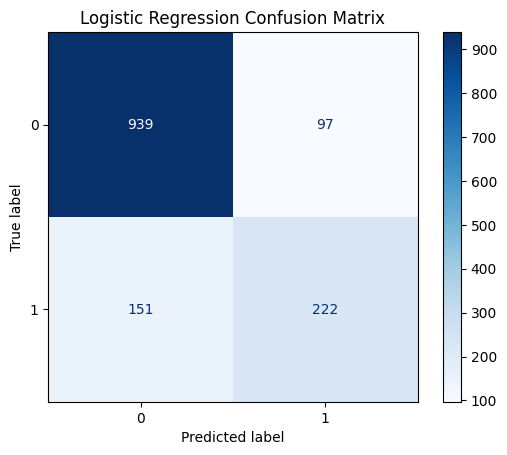

In [80]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

# Display confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Evaluate Random Forest

In [81]:
# Predict using Random Forest
y_pred_rf = random_forest_pipeline.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Random Forest Results
----------------------
Accuracy : 0.7920511000709723
Precision: 0.6470588235294118
Recall   : 0.4718498659517426
F1-Score : 0.5457364341085271


### Confusion metrics of Random Forest

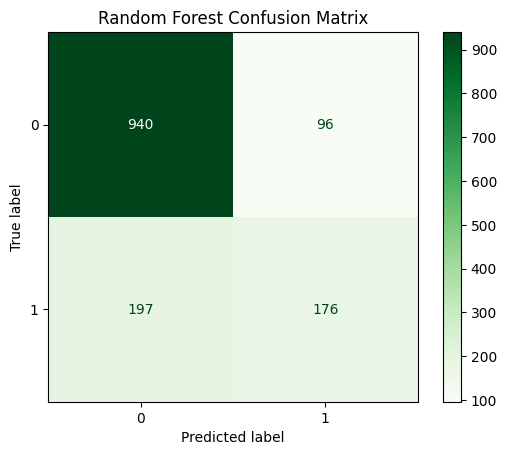

In [82]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")
plt.show()

## 10. Hyperparameter Tuning using GridSearchCV

### Import GridSearchCV

In [83]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

### Logistic Regression GridSearch

In [84]:
# Define parameter grid for Logistic Regression
logistic_params = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

In [85]:
# Perform Grid Search
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

logistic_grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotE...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=5000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [86]:
# Display best parameters
print("Best Logistic Regression Parameters:")
print(logistic_grid.best_params_)

print()

print("Best Accuracy:")
print(logistic_grid.best_score_)

Best Logistic Regression Parameters:
{'classifier__C': 0.01, 'classifier__solver': 'liblinear'}

Best Accuracy:
0.8010291551943969


### Random Forest GridSearch

In [87]:
# Define parameter grid for Random Forest
rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

In [88]:
# Perform Grid Search
rf_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotE...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

In [89]:
# Display best parameters
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print()

print("Best Accuracy:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Accuracy:
0.793041618531728


### Best Model (Comparison)

In [90]:
# Compare both tuned models
print("Best Logistic Regression Accuracy:")
print(logistic_grid.best_score_)

print()

print("Best Random Forest Accuracy:")
print(rf_grid.best_score_)

Best Logistic Regression Accuracy:
0.8010291551943969

Best Random Forest Accuracy:
0.793041618531728


### Comparing performance

In [92]:
# Compare the performance of both models

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.823989   0.695925  0.595174  0.641618
1        Random Forest  0.792051   0.647059  0.471850  0.545736


### Visual model comparison

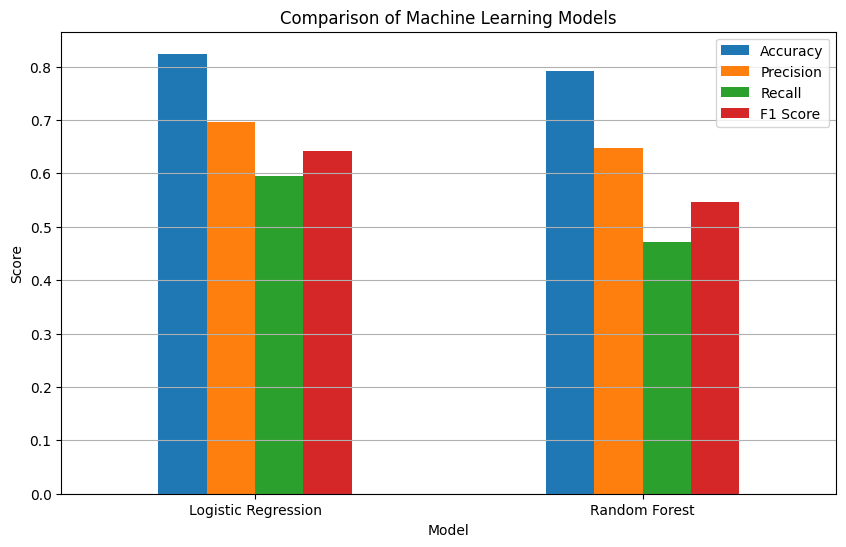

In [93]:
# Plot model comparison

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

## 11. Exporting Pipeline for Joblib

In [94]:
# Import joblib
import joblib

In [95]:
# Save the best trained pipeline

joblib.dump(
    logistic_grid.best_estimator_,
    "best_churn_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


### Loading the saved pipeline

In [96]:
# Load the saved pipeline

loaded_pipeline = joblib.load(
    "best_churn_pipeline.pkl"
)

print("Pipeline loaded successfully!")

Pipeline loaded successfully!


## 12. Predict on new customer data

In [97]:
# Create a new customer

new_customer = pd.DataFrame({

    'gender': ['Female'],
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['No'],
    'tenure': [24],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['Yes'],
    'DeviceProtection': ['Yes'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['No'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [75.50],
    'TotalCharges': [1812.00]

})

In [98]:
# Predict customer churn

prediction = loaded_pipeline.predict(
    new_customer
)

print("Prediction:", prediction)

Prediction: [0]


In [99]:
# Display prediction result

if prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")

The customer is likely to stay.


# Project Summary

This project developed an end-to-end machine learning pipeline to predict customer churn using the IBM Telco Customer Churn dataset. 
The dataset was preprocessed by handling missing values, encoding categorical features, scaling numerical features, and separating the target variable.
Scikit-learn's Pipeline and ColumnTransformer were used to automate the preprocessing workflow.

Two classification models, Logistic Regression and Random Forest, were trained and evaluated using Accuracy, Precision, Recall, F1-score, and Confusion
Matrix. GridSearchCV was applied to optimize model hyperparameters and improve prediction performance. 
The best-performing model was exported using Joblib, enabling it to be reused for predicting churn on new customer data.

This project demonstrates a complete production-ready machine learning workflow, covering data preprocessing, model training, evaluation, 
hyperparameter tuning, model comparison, and deployment-ready pipeline creation using Scikit-learn.